# 04 — Regression & Residual Analysis
**DSA210 Term Project · Nehir Eylül Balcı**

Fits simple and multiple linear regression models, compares men's vs women's,
and uses residuals to identify countries that over/under-perform relative to their GDP.

In [1]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset.csv


## 4.1 Simple Regression — Log GDP → Women's Points

β₀=-30.1  β₁=59.9  R²=0.059


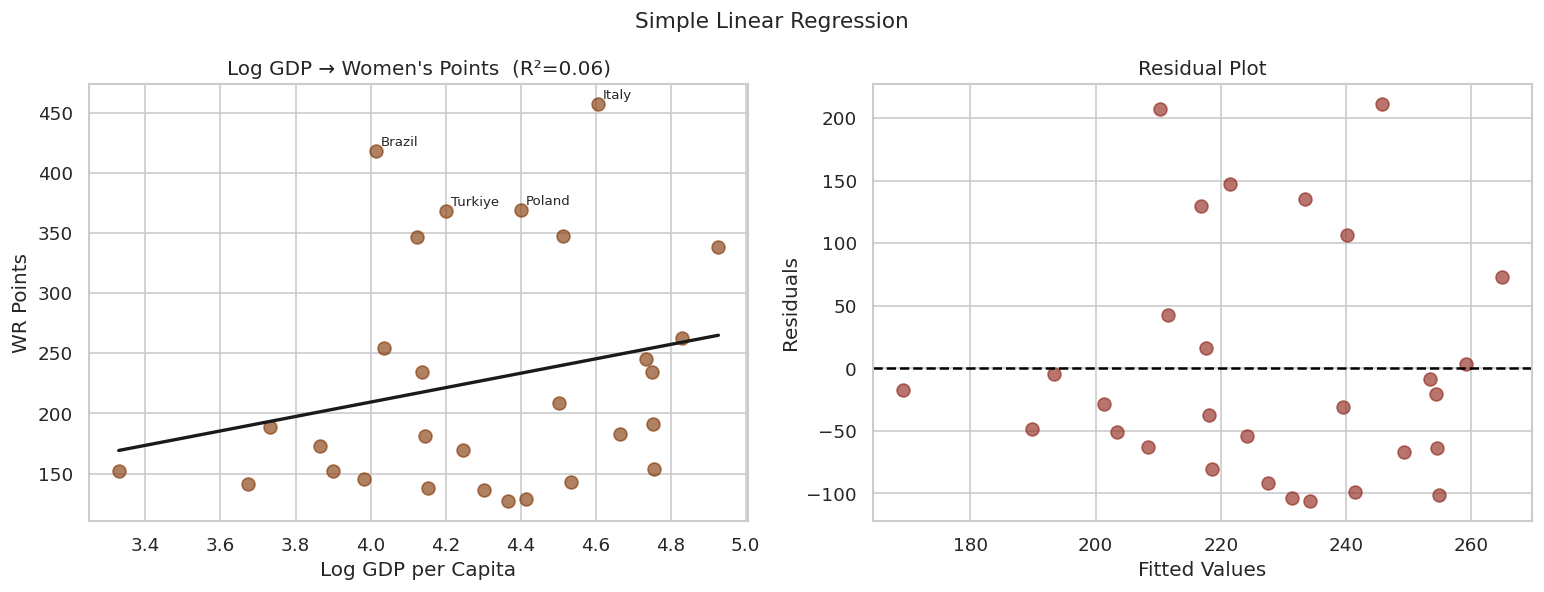

In [5]:
import warnings
warnings.filterwarnings('ignore')

tmp = df[["country_std","log_gdp","pts_women"]].dropna()
m = LinearRegression().fit(tmp[["log_gdp"]], tmp["pts_women"])
pred  = m.predict(tmp[["log_gdp"]])
resid = tmp["pts_women"].values - pred

print(f"β₀={m.intercept_:.1f}  β₁={m.coef_[0]:.1f}  R²={m.score(tmp[['log_gdp']],tmp['pts_women']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(tmp["log_gdp"], tmp["pts_women"], color="#843C0C", alpha=0.65, s=60)
xr = np.linspace(tmp["log_gdp"].min(), tmp["log_gdp"].max(), 100).reshape(-1,1)
axes[0].plot(xr, m.predict(xr), "k-", lw=2)
for _, row in tmp.nlargest(4,"pts_women").iterrows():
    axes[0].annotate(row["country_std"], (row["log_gdp"],row["pts_women"]),
                     fontsize=8, xytext=(3,3), textcoords="offset points")
axes[0].set_title(f"Log GDP → Women's Points  (R²={m.score(tmp[['log_gdp']],tmp['pts_women']):.2f})")
axes[0].set_xlabel("Log GDP per Capita"); axes[0].set_ylabel("WR Points")

axes[1].scatter(pred, resid, color="#922B21", alpha=0.65, s=60)
axes[1].axhline(0, color="black", ls="--", lw=1.5)
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Fitted Values"); axes[1].set_ylabel("Residuals")

plt.suptitle("Simple Linear Regression", fontsize=13)
plt.tight_layout()
plt.show()

# residuals look randomly scattered around 0 — the log transform helped with heteroskedasticity.

## 4.2 Multiple Regression — Men vs Women

,Gender,β Log GDP,β HDI,β Log Pop,R²
0,Women,-32.5,259.6,96.5,0.421
1,Men,-90.3,991.5,28.7,0.231


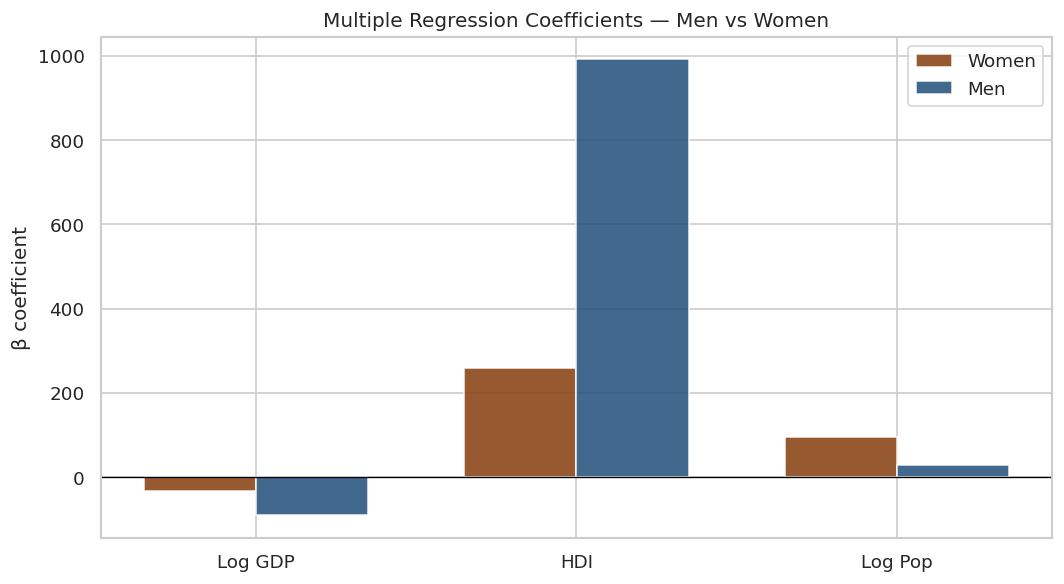

In [3]:
FEATS = ["log_gdp","hdi","log_population"]
reg   = df[["country_std"] + FEATS + ["pts_women","pts_men"]].dropna()

rows = []
for gender, col in [("Women","pts_women"),("Men","pts_men")]:
    m = LinearRegression().fit(reg[FEATS], reg[col])
    rows.append({"Gender": gender,
                 "β Log GDP":  round(m.coef_[0],1),
                 "β HDI":      round(m.coef_[1],1),
                 "β Log Pop":  round(m.coef_[2],1),
                 "R²":         round(m.score(reg[FEATS],reg[col]),3)})
comp = pd.DataFrame(rows)
display(comp)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3); w = 0.35
ax.bar(x-w/2, comp.iloc[0][["β Log GDP","β HDI","β Log Pop"]].values,
       w, label="Women", color="#843C0C", alpha=0.85)
ax.bar(x+w/2, comp.iloc[1][["β Log GDP","β HDI","β Log Pop"]].values,
       w, label="Men", color="#1F4E79", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(["Log GDP","HDI","Log Pop"])
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("β coefficient"); ax.legend()
ax.set_title("Multiple Regression Coefficients — Men vs Women", fontsize=12)
plt.tight_layout()
plt.show()

# HDI has the largest coefficient for both. it's notably bigger for women,
# suggesting women's volleyball is more tied to broad societal development.
# population coefficient is near-zero for both — consistent with everything so far.

## 4.3 Residual Analysis — Who Punches Above Their Weight?

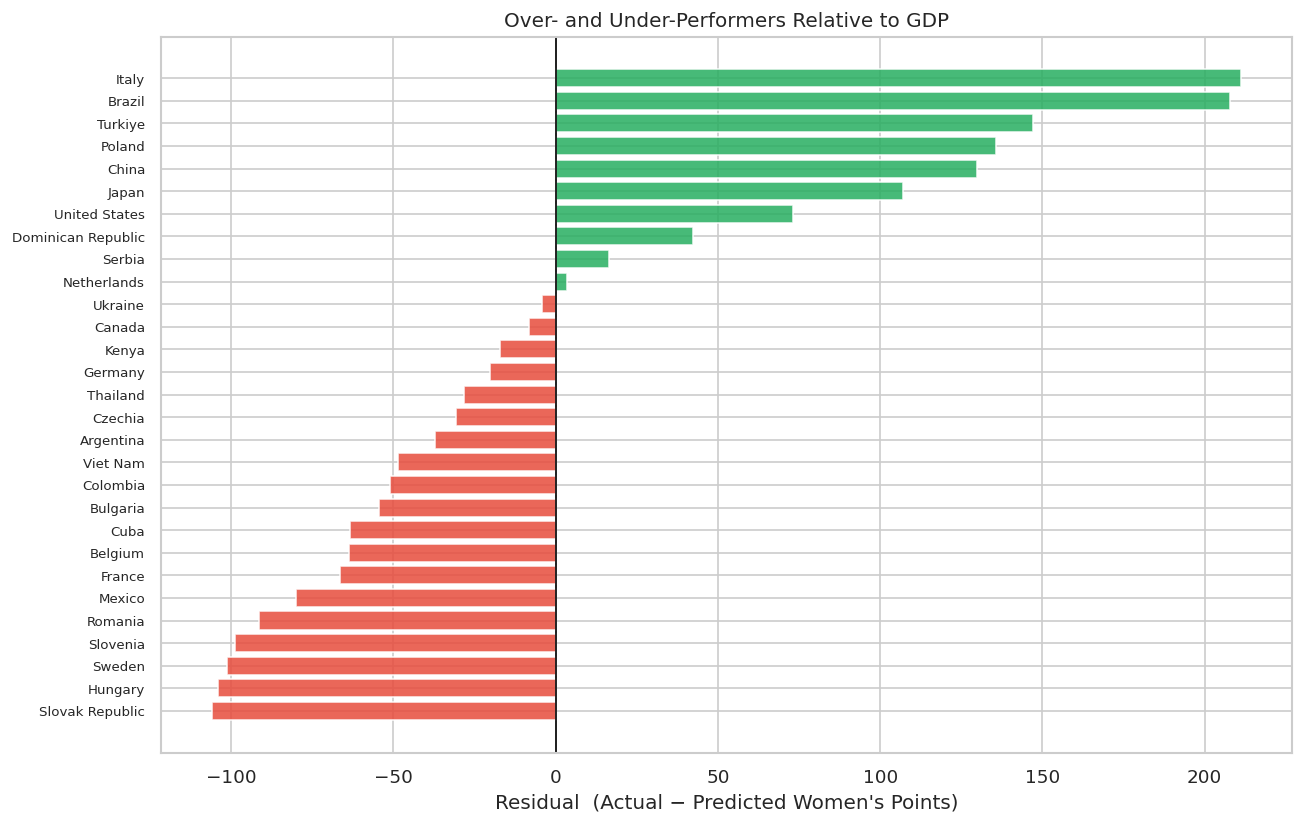

In [4]:
tmp_r = df[["country_std","log_gdp","pts_women"]].dropna().copy()
m_r   = LinearRegression().fit(tmp_r[["log_gdp"]], tmp_r["pts_women"])
tmp_r["predicted"] = m_r.predict(tmp_r[["log_gdp"]])
tmp_r["residual"]  = tmp_r["pts_women"] - tmp_r["predicted"]
tmp_r = tmp_r.sort_values("residual")

fig, ax = plt.subplots(figsize=(11, 7))
colors = ["#27AE60" if r > 0 else "#E74C3C" for r in tmp_r["residual"]]
ax.barh(tmp_r["country_std"], tmp_r["residual"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Residual  (Actual − Predicted Women's Points)")
ax.set_title("Over- and Under-Performers Relative to GDP", fontsize=12)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# Brazil and Turkey are the biggest over-performers by far.
# their success clearly comes from something GDP alone can't explain —
# probably volleyball culture, federation investment, and club infrastructure.
# some wealthy Gulf states show the opposite: high GDP, low volleyball success.